# 06 — Macro state panel (FRED → z-scores)

Extract three FRED series from `fred_series` and normalize as rolling z-scores. This panel is the input to the Monte Carlo regime engine (nb 07 — Phase 3/4).

| signal | FRED id | meaning |
|---|---|---|
| **Inflation velocity** | `CPIAUCSL` → YoY | price level acceleration |
| **Growth expectations** | `T10Y2Y` | 10Y–2Y Treasury spread; yield-curve inversion ⇒ recession signal |
| **Credit stress** | `BAMLH0A0HYM2` | ICE BofA HY Option-Adjusted Spread |

### Why this matters

Nb 04/05 showed that SPY B&H, EW B&H, and the pinned HRP+BL portfolio all took ~12–34% drawdowns in 2022. Annual rebalancing alone doesn't rescue a portfolio from a macro regime shift — inflation shock + yield-curve inversion + credit widening hit every risk asset simultaneously. The z-scored panel below is the state variable we'll bootstrap from to estimate forward regime probabilities.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

import macro_framework as mf

pd.set_option("display.width", 180)

## 1. Raw series

In [2]:
cpi_level = mf.load_fred_series("CPIAUCSL")
t10y2y    = mf.load_fred_series("T10Y2Y")
hy_oas    = mf.load_fred_series("BAMLH0A0HYM2")

print(f"CPIAUCSL       {len(cpi_level):>5} obs  {cpi_level.index.min().date()} → {cpi_level.index.max().date()}  ({cpi_level.index.inferred_freq})")
print(f"T10Y2Y         {len(t10y2y):>5} obs  {t10y2y.index.min().date()} → {t10y2y.index.max().date()}")
print(f"BAMLH0A0HYM2   {len(hy_oas):>5} obs  {hy_oas.index.min().date()} → {hy_oas.index.max().date()}")

CPIAUCSL         194 obs  2010-01-01 → 2026-03-01  (None)
T10Y2Y          4075 obs  2010-01-04 → 2026-04-17
BAMLH0A0HYM2    4255 obs  2010-01-04 → 2026-04-16


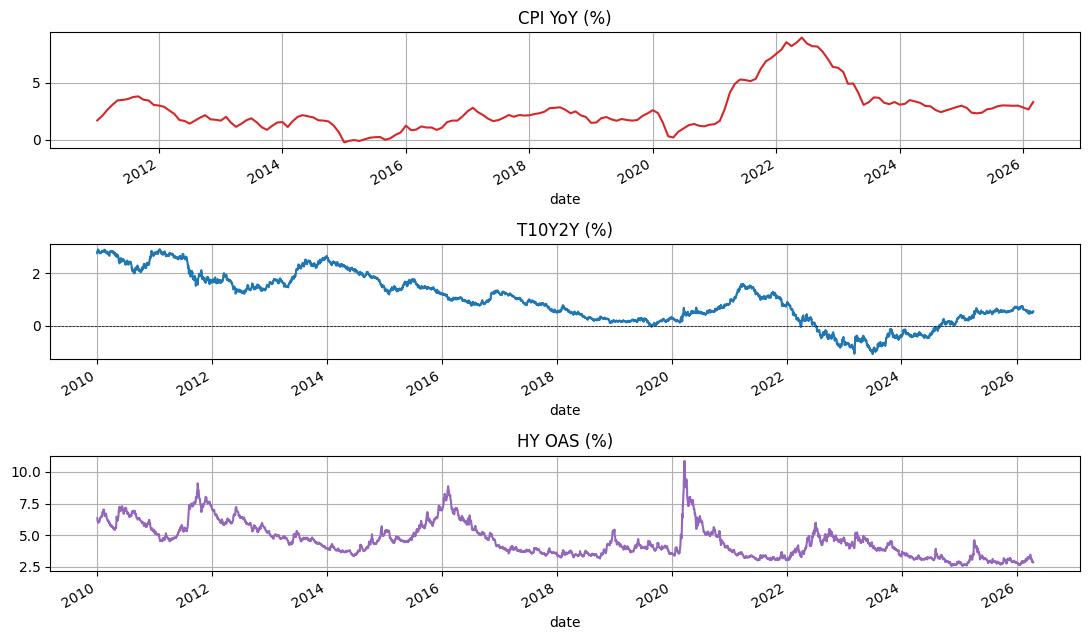

In [3]:
import matplotlib.pyplot as plt

inflation = mf.cpi_yoy(cpi_level)
fig, axes = plt.subplots(3, 1, figsize=(11, 6.5))
inflation.plot(ax=axes[0], title="CPI YoY (%)", grid=True, color="tab:red")
t10y2y.plot(ax=axes[1],  title="T10Y2Y (%)",   grid=True, color="tab:blue")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
hy_oas.plot(ax=axes[2],  title="HY OAS (%)",   grid=True, color="tab:purple")
fig.tight_layout();

## 2. Aligned monthly panel + rolling z-scores

`build_macro_panel` resamples every series to month-end, then applies a 5-year rolling z-score (60 monthly obs). Rolling (rather than full-sample) avoids look-ahead bias when we use these as features in a real-time allocation.

In [4]:
panel = mf.build_macro_panel(zscore_window=60)
print(f"panel: {panel.shape}  ({panel.index.min().date()} → {panel.index.max().date()})")
panel.tail(6).round(3)

panel: (196, 6)  (2010-01-31 → 2026-04-30)


,cpi_yoy,t10y2y,hy_oas,cpi_yoy_z,t10y2y_z,hy_oas_z
date,,,,,,
2025-11-30,2.988,0.55,2.92,-0.691,0.563,-1.018
2025-12-31,3.002,0.71,2.81,-0.708,0.801,-1.135
2026-01-31,2.829,0.74,2.88,-0.810,0.857,-1.008
2026-02-28,2.665,0.59,3.12,-0.903,0.667,-0.667
2026-03-31,3.320,0.51,3.28,-0.601,0.596,-0.447
2026-04-30,NaN,0.55,2.86,NaN,0.709,-1.002


## 3. Z-score visualization with crisis bands

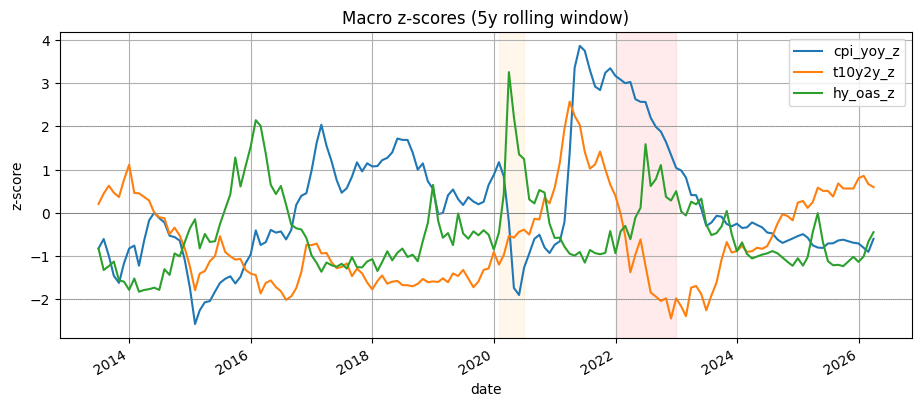

In [5]:
z = panel[["cpi_yoy_z", "t10y2y_z", "hy_oas_z"]].dropna()

ax = z.plot(figsize=(11, 4.5), grid=True, title="Macro z-scores (5y rolling window)")
for lvl, style in [(2.0, ":"), (-2.0, ":"), (0.0, "-")]:
    ax.axhline(lvl, color="grey", linewidth=0.6, linestyle=style)
# 2022 regime band
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), color="red", alpha=0.08)
# 2020 COVID band
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-30"), color="orange", alpha=0.08)
ax.set_ylabel("z-score");

## 4. Zoom — 2022 stress cluster

CPI z-score at **+3σ** tail (inflation shock), T10Y2Y at **−2σ** (deep curve inversion), HY OAS spiking to **+1.6σ** (credit stress). Three independent regime signals firing together — textbook stagflation/recession risk.

In [6]:
crisis_2022 = panel.loc["2022-01":"2022-12"][["cpi_yoy", "cpi_yoy_z", "t10y2y", "t10y2y_z", "hy_oas", "hy_oas_z"]].round(3)
crisis_2022

,cpi_yoy,cpi_yoy_z,t10y2y,t10y2y_z,hy_oas,hy_oas_z
date,,,,,,
2022-01-31,7.559,3.084,0.61,-0.018,3.63,-0.432
2022-02-28,7.937,3.001,0.39,-0.541,3.77,-0.301
2022-03-31,8.572,3.030,0.04,-1.376,3.43,-0.610
2022-04-30,8.232,2.631,0.19,-0.965,3.97,-0.109
2022-05-31,8.538,2.571,0.32,-0.614,4.22,0.117
2022-06-30,8.979,2.567,0.06,-1.229,5.87,1.590
2022-07-31,8.463,2.202,-0.22,-1.845,4.83,0.620
2022-08-31,8.223,1.991,-0.30,-1.938,5.03,0.781
2022-09-30,8.192,1.882,-0.39,-2.039,5.43,1.107


## 5. Motivation — macro stress vs portfolio drawdown

Overlay the 2022 drawdown of the pinned HRP+BL strategy (nb 05) with the first principal component of |macro z|: when macro z-scores go extreme in aggregate, the portfolio draws down.

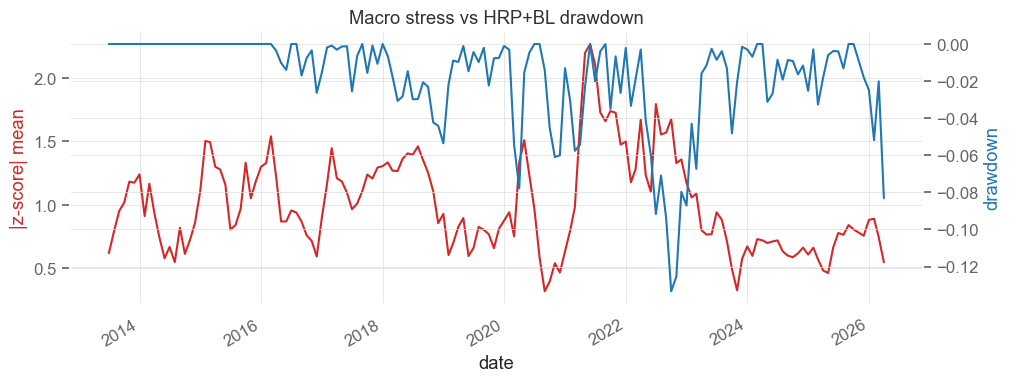

In [7]:
import matplotlib.pyplot as plt

spec = pd.read_parquet(Path.cwd().parent / "data" / "portfolio_ssr_top_per_category.parquet")
SYMBOLS = spec["symbol"].tolist()
prices = mf.get_prices(SYMBOLS, start="2013-01-01", end="2026-03-31")
rb_dates = mf.annual_rebalance_dates(prices, start="2016-01-31")

VIEW_P = pd.DataFrame([[1, 0, 0, -1]], columns=SYMBOLS)
VIEW_Q = pd.DataFrame([[0.05 / 252]])

def strat_c(r):
    w_hrp = mf.hrp_cvar_weights_with_fixed(r, {"BIL": 0.25})
    w_bl = mf.bl_mv_weights(r, prior_weights=w_hrp, P=VIEW_P, Q=VIEW_Q, obj="Utility")
    w = 0.7 * w_hrp + 0.3 * w_bl
    return w / w.sum()

targets = mf.build_target_weights(prices[SYMBOLS], strat_c, rb_dates, lookback_days=756)
pf = mf.run_rebalance_sim(prices[SYMBOLS], targets, init_cash=10_000.0)

dd_monthly = pf.drawdown().resample("ME").last()
macro_stress = z.abs().mean(axis=1).rename("|macro z| mean")
overlay = pd.concat([macro_stress, dd_monthly.rename("HRP+BL drawdown")], axis=1).dropna()

fig, ax1 = plt.subplots(figsize=(11, 4))
overlay["|macro z| mean"].plot(ax=ax1, color="tab:red", grid=True)
ax1.set_ylabel("|z-score| mean", color="tab:red")
ax2 = ax1.twinx()
overlay["HRP+BL drawdown"].plot(ax=ax2, color="tab:blue")
ax2.set_ylabel("drawdown", color="tab:blue")
ax1.set_title("Macro stress vs HRP+BL drawdown");

## 6. Persist panel

In [8]:
out = Path.cwd().parent / "data" / "macro_panel_monthly.parquet"
panel.to_parquet(out)
print(f"wrote {out.relative_to(Path.cwd().parent)}  ({panel.shape[0]} months × {panel.shape[1]} cols)")

wrote data/macro_panel_monthly.parquet  (196 months × 6 cols)
